In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import scipy as sp

try:
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "text.latex.preamble": r"\usepackage{amsmath}",
    })
except Exception as e:
    print(f"Could not enable LaTeX rendering: {e}\nFalling back to default.")

In [42]:
data = pd.read_parquet(r"C:\Users\rossi\Documents\tesi\apdl\sim\sim_0.006_0.024.parquet")
t = 0.001

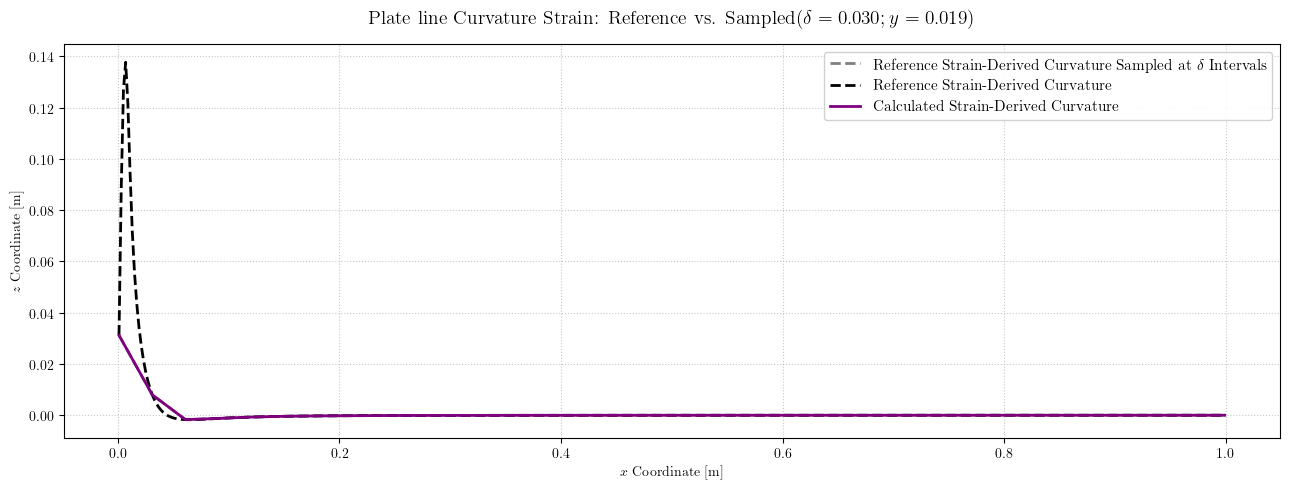

In [43]:
delta = 0.030
Y = 0.019
line_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6) & Y == @Y | X == 0.999 & Y == @Y')
curvature_line = -line_data['EXX']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()

cs_strain = sp.interpolate.CubicSpline(x_coords, curvature_line)
ad1 = cs_strain.antiderivative()
slope = ad1(x_coords) - ad1(x_coords[0])
cs_slope = sp.interpolate.CubicSpline(x_coords, slope)
ad2 = cs_slope.antiderivative()
z_disp = ad2(x_coords) - ad2(x_coords[0])
z_disp = z_disp - z_disp[-1] / np.max(x_coords) * x_coords


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['X'].unique(), curvature_line, 
         label='Reference Strain-Derived Curvature Sampled at $\\delta$ Intervals', 
         color='gray', 
         linestyle='--', 
         linewidth=2)

ax.plot(data['X'].unique(), -data.query(f'Y == @Y')['EXX']/t, 
         label='Reference Strain-Derived Curvature', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['X'].unique(), cs_strain(x_coords), 
         label='Calculated Strain-Derived Curvature', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Curvature Strain: Reference vs. Sampled' + f'($\\delta = {delta:.3f}; y = {Y:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

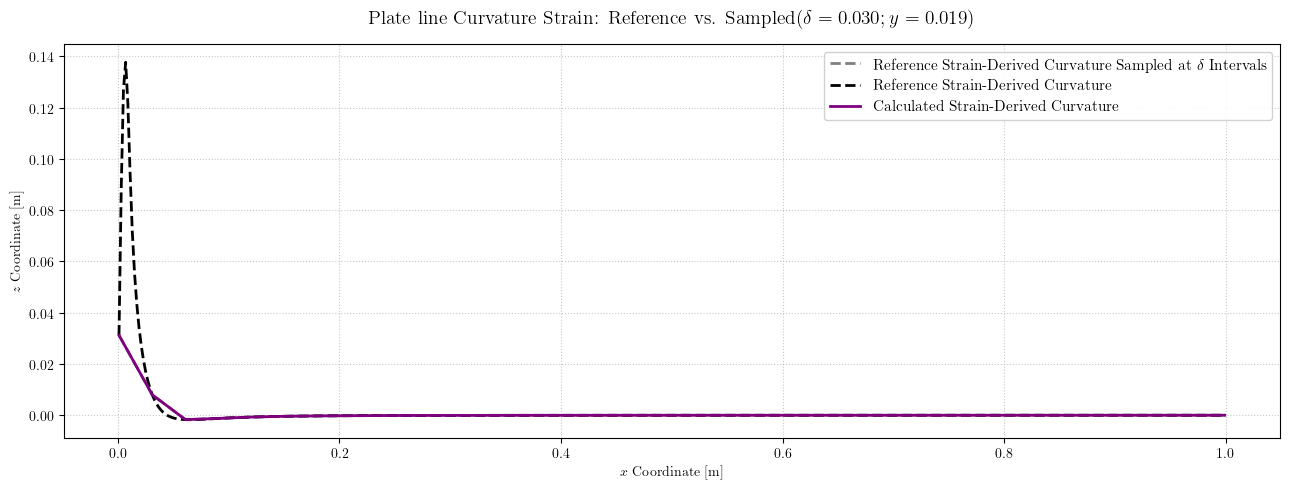

In [44]:
# delta = 0.10
Y = 0.019
line_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6) & Y == @Y | X == 0.999 & Y == @Y')
curvature_line = -line_data['EXX']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()
# strain_poly = np.polynomial.Polynomial.fit(x_coords, curvature_line, deg=len(x_coords)-1)
# z_disp = strain_poly.integ().integ()(x_coords) - strain_poly.integ().integ()(x_coords[0]) # double integral
# z_disp = z_disp - z_disp[-1] / np.max(x_coords) * x_coords # boudary condition z[a] == 0

# strain_poly_b = np.polynomial.Polynomial.fit(x_coords, curvature_line[::-1], deg=len(x_coords)-1)
# z_disp_b = strain_poly_b.integ().integ()(x_coords) - strain_poly_b.integ().integ()(x_coords[0]) # double integral
# z_disp_b = z_disp_b - z_disp_b[-1] / np.max(x_coords) * x_coords # boudary condition z[a] == 0



cs_strain = sp.interpolate.CubicSpline(x_coords, curvature_line)
ad1 = cs_strain.antiderivative()
slope = ad1(x_coords) - ad1(x_coords[0])
cs_slope = sp.interpolate.make_interp_spline(x_coords, slope, bc_type='natural')
ad2 = cs_slope.antiderivative()
z_disp = ad2(x_coords) - ad2(x_coords[0])
z_disp = z_disp - z_disp[-1] / np.max(x_coords) * x_coords


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['X'].unique(), curvature_line, 
         label='Reference Strain-Derived Curvature Sampled at $\\delta$ Intervals', 
         color='gray', 
         linestyle='--', 
         linewidth=2)

ax.plot(data['X'].unique(), -data.query(f'Y == @Y')['EXX']/t, 
         label='Reference Strain-Derived Curvature', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['X'].unique(), cs_strain(line_data['X'].unique()), 
         label='Calculated Strain-Derived Curvature', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Curvature Strain: Reference vs. Sampled' + f'($\\delta = {delta:.3f}; y = {Y:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

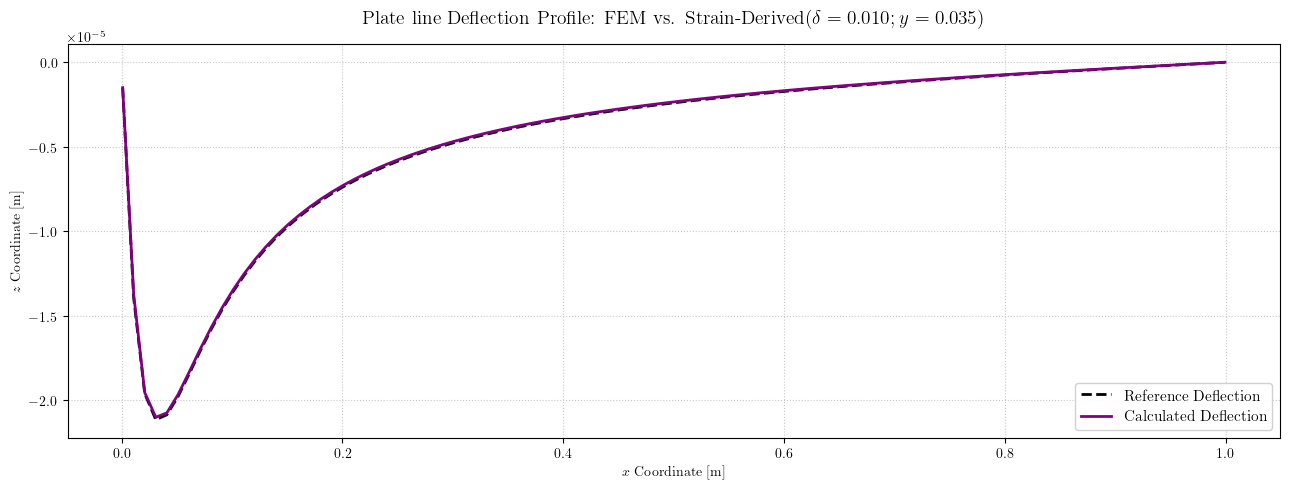

In [45]:
delta = 0.010
Y = 0.035
line_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6) & Y == @Y | X == 0.999 & Y == @Y')
curvature_line = -line_data['EXX']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()

ad1 = sp.interpolate.CubicSpline(x_coords, curvature_line).antiderivative()
ad2 = sp.interpolate.CubicSpline(x_coords, ad1(x_coords)).antiderivative()
z_disp = ad2(x_coords) - ad2(x_coords[-1]) / np.max(x_coords) * x_coords


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['X'].unique(), line_data['Z'], 
         label='Reference Deflection', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['X'].unique(), z_disp, 
         label='Calculated Deflection', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Deflection Profile: FEM vs. Strain-Derived' + f'($\\delta = {delta:.3f}; y = {Y:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

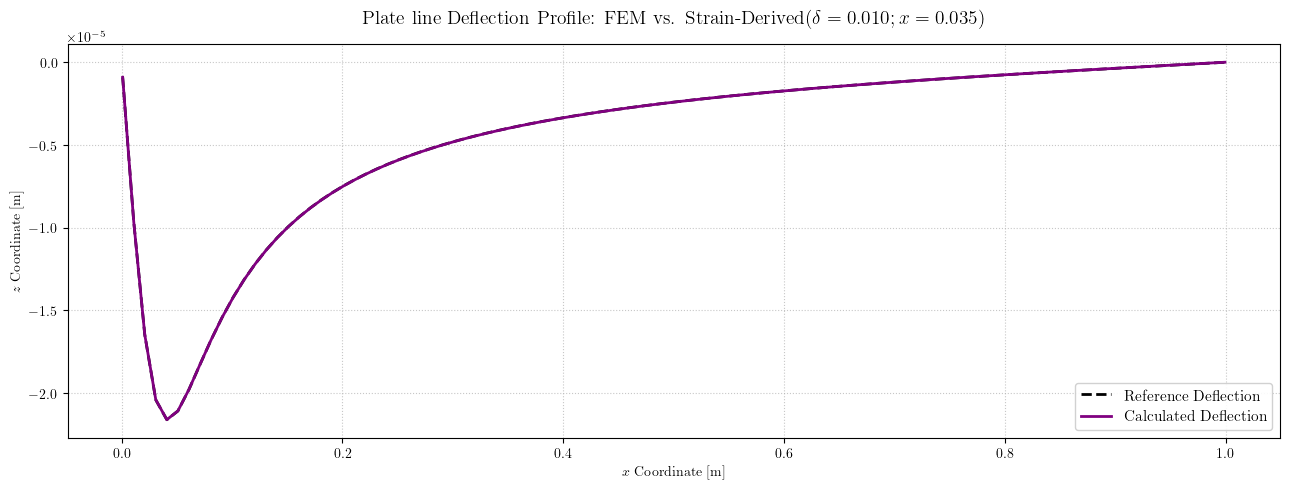

In [46]:
X = 0.035
line_data = data.query(f'(abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)) & X == @X | X == @X & Y == 0.999')
curvature_line = -line_data['EYY']/t
x_coords = line_data['X'].unique()
y_coords = line_data['Y'].unique()
ad1 = sp.interpolate.CubicSpline(y_coords, curvature_line).antiderivative()
ad2 = sp.interpolate.CubicSpline(y_coords, ad1(y_coords)).antiderivative()
z_disp = ad2(y_coords) - ad2(y_coords[-1]) / np.max(y_coords) * y_coords


fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(line_data['Y'].unique(), line_data['Z'], 
         label='Reference Deflection', 
         color='black', 
         linestyle='--', 
         linewidth=2)

# Plot 2: Calculated Data from Strain
ax.plot(line_data['Y'].unique(), z_disp, 
         label='Calculated Deflection', 
         color='purple', 
         linewidth=2)

# Titles and Axis Labels
# (Note: Update 'm' to 'mm' or 'in' if your data uses different units)
ax.set_title('Plate line Deflection Profile: FEM vs. Strain-Derived' + f'($\\delta = {delta:.3f}; x = {X:.3f})$', fontsize=14, pad=15)
ax.set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
ax.set_ylabel(r"$z$ Coordinate $\left[\mathrm{m}\right]$")

# Grid and Legend
ax.grid(True, linestyle=':', alpha=0.7)
ax.legend(loc='best', fontsize=11, framealpha=0.9)

# Clean up layout margins and render
plt.tight_layout()
plt.show()

In [ ]:
sampled_data = data.query(f'abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, y in enumerate(y_coords):
    line_data = sampled_data.query('abs(Y - @y) < 1e-6')
    curvature_line = -line_data['EXX']/t
    ad1 = sp.interpolate.CubicSpline(x_coords, curvature_line).antiderivative()
    ad2 = sp.interpolate.CubicSpline(x_coords, ad1(x_coords)).antiderivative()
    z_grid[:, j] = ad2(x_coords) - ad2(x_coords[-1]) / np.max(x_coords) * x_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta']
symbol = [r'$w$ reference', r'$w$ calculated along $y$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

ValueError: operands could not be broadcast together with shapes (50000,) (5000,) 

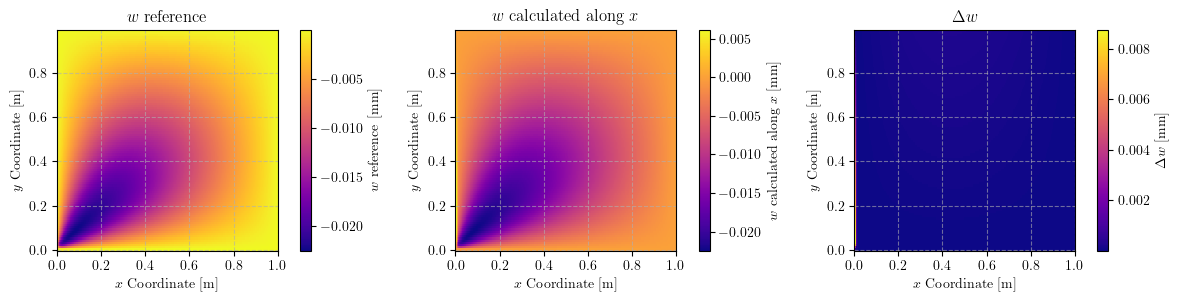

In [48]:
sampled_data = data.query(f'abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    ad1 = sp.interpolate.CubicSpline(y_coords, curvature_line).antiderivative()
    ad2 = sp.interpolate.CubicSpline(y_coords, ad1(y_coords)).antiderivative()
    z_grid[j, :] = ad2(y_coords) - ad2(y_coords[-1]) / np.max(y_coords) * y_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta']
symbol = [r'$w$ reference', r'$w$ calculated along $x$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

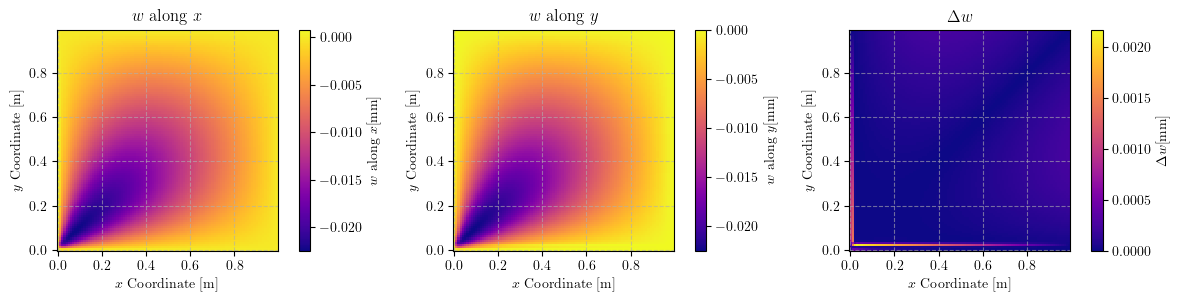

In [49]:
sampled_data = data.query(f'(abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)) & (abs(((X - 0.001)) % @delta < 1e-6 | abs((X - 0.001) % @delta - @delta) < 1e-6))')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid_x = np.ndarray((len(x_coords), len(y_coords)))
z_grid_y = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    ad1 = sp.interpolate.CubicSpline(y_coords, curvature_line).antiderivative()
    ad2 = sp.interpolate.CubicSpline(y_coords, ad1(y_coords)).antiderivative()
    z_grid_x[j, :] = ad2(y_coords) - ad2(y_coords[-1]) / np.max(y_coords) * y_coords # boudary condition z[a] == 0

for j, y in enumerate(y_coords):
    line_data = sampled_data.query('abs(Y - @y) < 1e-6')
    curvature_line = -line_data['EXX']/t
    ad1 = sp.interpolate.CubicSpline(x_coords, curvature_line).antiderivative()
    ad2 = sp.interpolate.CubicSpline(x_coords, ad1(x_coords)).antiderivative()
    z_grid_y[:, j] = ad2(x_coords) - ad2(x_coords[-1]) / np.max(x_coords) * x_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z_calc_x': z_grid_x.flatten(order='F') * 1e3,
    'Z_calc_y': z_grid_y.flatten(order='F') * 1e3,
    'delta' : np.abs(z_grid_x.flatten(order='F') - z_grid_y.flatten(order='F')) * 1e3
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(12, 3))

# Define the components to iterate over to avoid repeating code
components = ['Z_calc_x', 'Z_calc_y', 'delta']
symbol = [r'$w$ along $x$', r'$w$ along $y$', r'$\Delta w$']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]}"+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

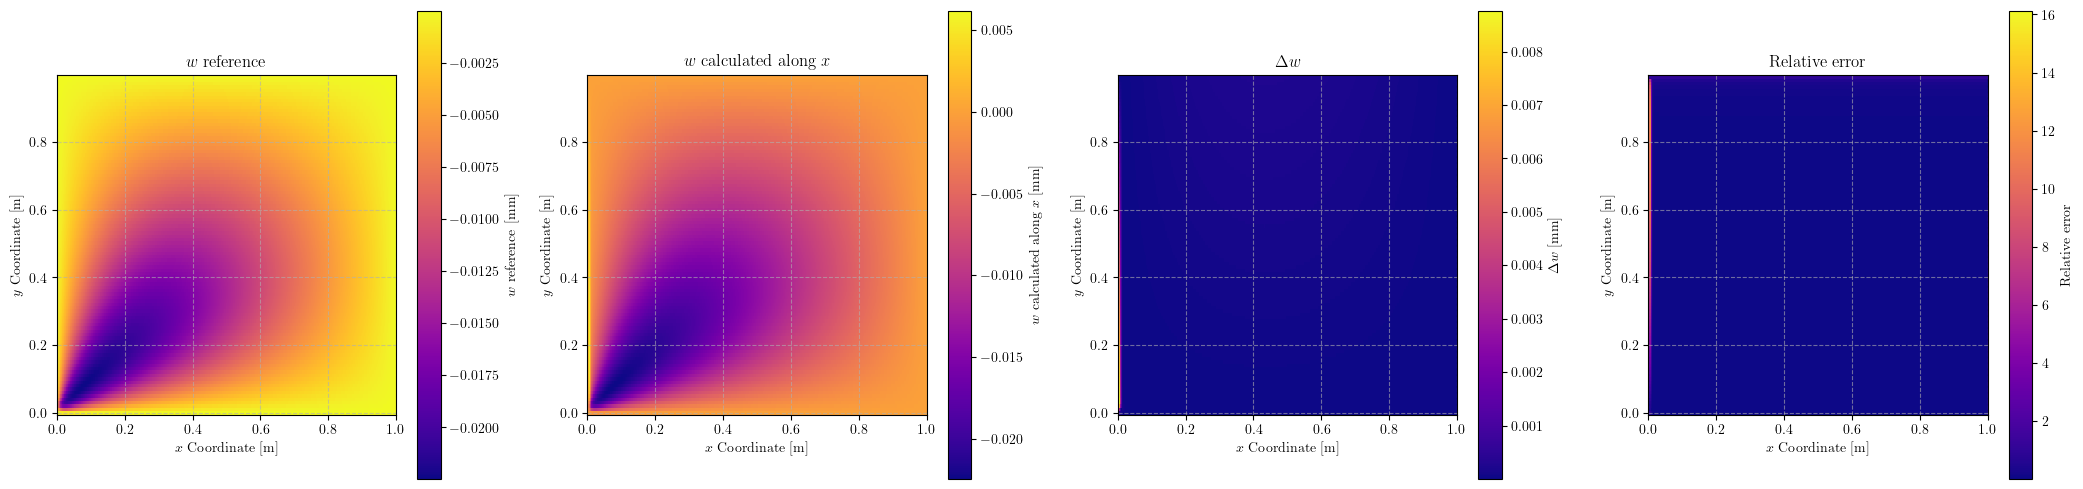

In [50]:
sampled_data = data.query(f'abs(((Y - 0.001)) % @delta < 1e-6 | abs((Y - 0.001) % @delta - @delta) < 1e-6)')
x_coords = sampled_data['X'].unique()
y_coords = sampled_data['Y'].unique()


z_grid = np.ndarray((len(x_coords), len(y_coords)))

for j, x in enumerate(x_coords):
    line_data = sampled_data.query('abs(X - @x) < 1e-6')
    curvature_line = -line_data['EYY']/t
    ad1 = sp.interpolate.CubicSpline(y_coords, curvature_line).antiderivative()
    ad2 = sp.interpolate.CubicSpline(y_coords, ad1(y_coords)).antiderivative()
    z_grid[j, :] = ad2(y_coords) - ad2(y_coords[-1]) / np.max(y_coords) * y_coords # boudary condition z[a] == 0

print_df = pd.DataFrame({
    'X': sampled_data['X'],
    'Y': sampled_data['Y'],
    'Z': sampled_data['Z'] * 1e3,
    'Z_calc': z_grid.flatten(order='F') * 1e3,
    'delta' : np.abs(sampled_data['Z'].values - z_grid.flatten(order='F')) * 1e3,
    'relative' : np.abs((sampled_data['Z'].values - z_grid.flatten(order='F'))/sampled_data['Z'].values),
})

fig, ax = plt.subplots(1, len(print_df.columns)-2, figsize=(21, 5))

# Define the components to iterate over to avoid repeating code
components = ['Z', 'Z_calc', 'delta', 'relative']
symbol = [r'$w$ reference', r'$w$ calculated along $x$', r'$\Delta w$', r'Relative error']
legend = [r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'$\left[\mathrm{mm}\right]$', r'']

for i, component in enumerate(components):
    # Pivot the dataframe to get a 2D grid of the difference values
    print_pivot = print_df.pivot(index='Y', columns='X', values=component)

    x_coords = print_pivot.columns.to_numpy()
    y_coords = print_pivot.index.to_numpy()
    C = print_pivot.to_numpy()

    X_mesh, Y_mesh = np.meshgrid(x_coords, y_coords)

    # Plot the pcolormesh specifically on the current axis (ax[i])
    colormesh = ax[i].pcolormesh(X_mesh, Y_mesh, C, cmap="plasma", shading='auto', rasterized=True)

    # Add colorbar to the figure, specifying which axis it belongs to
    cbar = fig.colorbar(colormesh, ax=ax[i], label=f"{symbol[i]} "+ legend[i])
    
    # Use 'set_' methods for axis properties
    ax[i].set_xlabel(r"$x$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_ylabel(r"$y$ Coordinate $\left[\mathrm{m}\right]$")
    ax[i].set_title(f"{symbol[i]}")
    ax[i].axis("scaled") # Ensures the geometry isn't distorted
    ax[i].grid(True, linestyle='--', alpha=0.6)

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()